<div
  style="
    background-color: #f0f0f0;
    color:rgb(56, 56, 56);
    padding: 8px;
    display: flex;
    align-items: center;
    gap: 100px;
  "
>
  <img src="https://github.com/Angel-ISO/Deeplearning/blob/main/Week2/images/brand.svg?raw=1" style="max-height: 80px;">
  <strong>
    AI Saga: Deep Learning & Generative AI</br>
    2.Lab GAN Explorer — CNN as Discriminators and Bias Detection</br>
  </strong>
  <emph>
    Student Name: Angel Iso</br>
    Date: 2026-05-05</br>
  </emph>
</div>

### Background

In this lab I explore how CNNs work as **"critics"** inside a **Generative Adversarial Network (GAN)**. The point is to understand that a CNN is not only a classifier: inside a GAN it plays the role of the **discriminator**, judging how real or fake the images produced by the generator look.

I work on **Fashion-MNIST** (10 clothing classes, 28×28 grayscale images). The plan is:

1. **Part 1 — Understanding the discriminator**: implement and train a baseline DCGAN, then modify the discriminator (layers and kernels) and compare loss curves, confidence distributions and visual quality.
2. **Part 2 — Bias detection and critical analysis**: review the class balance, detect systematic per-class failures in what the model generates, document examples of bias, test a **mitigation strategy**, and close with an **ethical reflection**.

> Note: the Kaggle dataset linked in the original instructions is a generic CV one, but the activity explicitly asks to run the GAN on **Fashion-MNIST**, which is what I use here (loaded directly from `torchvision.datasets`).

---

### Deliverables

Notebook **2.lab.1-gan-explorer-fashion-mnist.ipynb** with:

- Documented discriminator modifications with before/after comparisons.
- Visualizations: generated samples at 3 checkpoints, discriminator confidence distributions (real vs fake), 2-3 documented bias / failure-mode examples.
- Markdown analysis covering: how the discriminator architecture affects generation quality, identified biases and their sources, the tested mitigation and its effectiveness, and a brief ethical reflection.
- Lab conclusions.

## 0. Imports and setup

I import the libraries I will use throughout the lab. The core piece is **PyTorch** plus `torchvision`, which gives me direct access to Fashion-MNIST without having to download it manually. I fix the random seeds so my experiments stay reproducible, and detect whether a GPU is available (in my case I train on CPU, but the same code runs on Colab with CUDA).

In [9]:
import os
import math
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

Using device: cpu


## 1. Loading and exploring Fashion-MNIST

Fashion-MNIST contains 60,000 training images of 28×28 pixels across 10 classes (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot). Before touching the GAN I check the class balance, because **Part 2** of this lab asks me to analyse class imbalances.

I normalize images to `[-1, 1]` because my generator ends with `Tanh`, so reals and fakes live in the same range.

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_set = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Train size: {len(train_set)} | Test size: {len(test_set)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 280kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.74MB/s]

Train size: 60000 | Test size: 10000


/tmp/ipykernel_7802/3165145131.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='count', data=counts_df, palette='viridis', ax=ax)


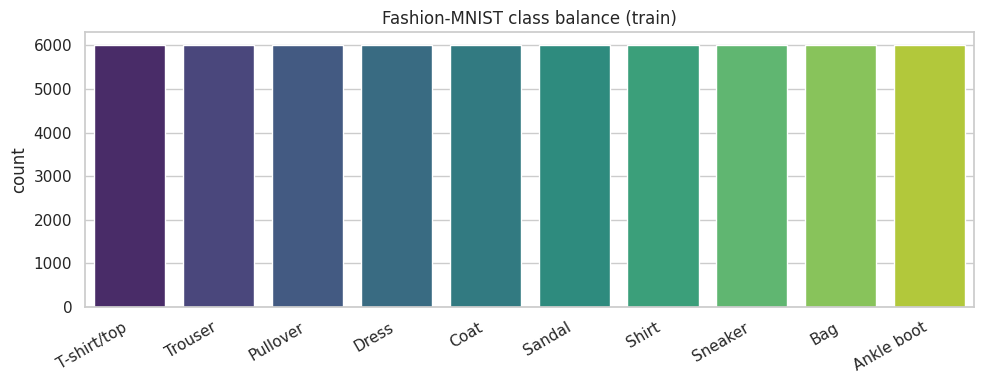

,class,count
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


In [11]:
train_labels = np.array(train_set.targets)
class_counts = Counter(train_labels.tolist())
counts_df = pd.DataFrame(
    {'class': class_names, 'count': [class_counts[i] for i in range(10)]}
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x='class', y='count', data=counts_df, palette='viridis', ax=ax)
ax.set_title('Fashion-MNIST class balance (train)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

counts_df

The original dataset is **perfectly balanced** (6,000 samples per class). This means that any bias I observe later on what the GAN produces is **not caused by class imbalance**, but by other factors: visual similarity between classes (Pullover, Coat and Shirt look very alike), mode collapse, or discriminator decisions.

To force a scenario where I can actually **test a mitigation**, later on I will build a **deliberately imbalanced** version of the dataset and compare what the GAN learns in each case.

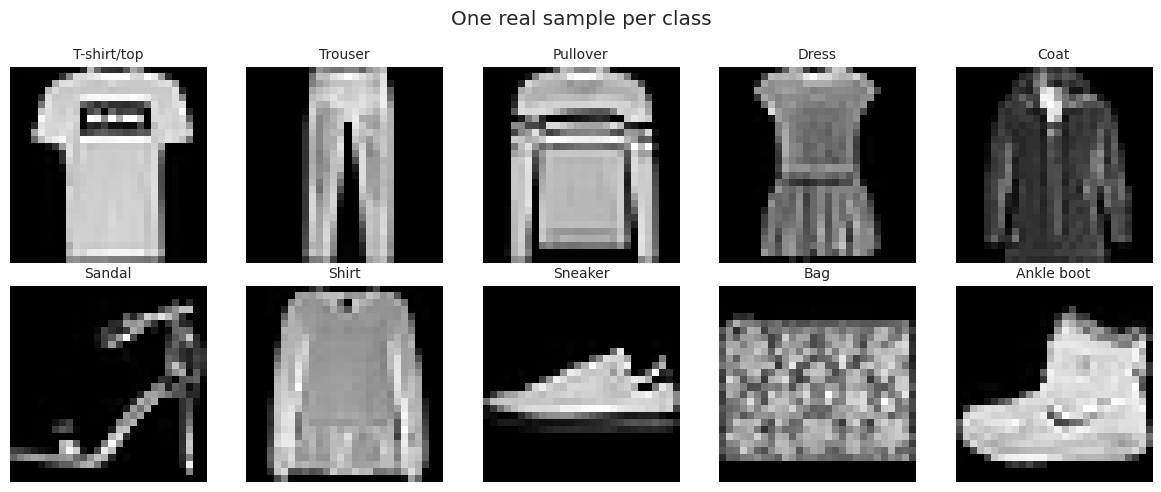

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls in range(10):
    idx = np.where(train_labels == cls)[0][0]
    img, _ = train_set[idx]
    ax = axes[cls // 5, cls % 5]
    ax.imshow(img.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    ax.set_title(class_names[cls], fontsize=10)
    ax.axis('off')
plt.suptitle('One real sample per class')
plt.tight_layout()
plt.show()

## 2. Baseline GAN architecture (DCGAN)

My GAN has two networks:

- **Generator**: takes a latent vector `z` of dimension 100 and turns it into a 1×28×28 image through `ConvTranspose2d` layers. It ends with `Tanh` to produce values in `[-1, 1]`.
- **Discriminator (CNN)**: the protagonist of this lab. It is a CNN that takes a 1×28×28 image and outputs a single scalar (logit) representing how "real" it considers it. I use `LeakyReLU` (the GAN standard) and `BatchNorm` in the intermediate layers.

The **discriminator is literally a binary CNN classifier** (real vs fake), with the twist that its "ground truth" shifts every epoch as the generator improves.

In [13]:
Z_DIM = 100
IMG_CH = 1

class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, img_channels=IMG_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class DiscriminatorBase(nn.Module):
    def __init__(self, img_channels=IMG_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0),
        )

    def forward(self, x):
        return self.net(x).view(-1)


g_test = Generator().to(device)
d_test = DiscriminatorBase().to(device)
z = torch.randn(4, Z_DIM, 1, 1, device=device)
fake = g_test(z)
score = d_test(fake)
print("Generator output shape:", fake.shape)
print("Discriminator output shape:", score.shape)
print("Generator params:", sum(p.numel() for p in g_test.parameters()))
print("Discriminator params:", sum(p.numel() for p in d_test.parameters()))

Generator output shape: torch.Size([4, 1, 28, 28])
Discriminator output shape: torch.Size([4])
Generator params: 1781504
Discriminator params: 138689


## 3. GAN training loop

I define a reusable `train_gan` function because later I will train several variants (baseline discriminator, modified discriminator, and balanced vs imbalanced versions). On every epoch:

1. For each batch of real images:
   - **Discriminator**: compute loss on real images (target=1) and on generated fakes (target=0), backprop and update.
   - **Generator**: generate new fakes and push the discriminator to classify them as real (target=1), backprop and update.
2. At the end of each epoch I store: losses, mean discriminator confidences, and — at chosen checkpoints — a grid of samples generated from a fixed `z` (so I can compare evolution apples-to-apples).

In [14]:
def train_gan(generator, discriminator, dataloader, epochs=15, lr=2e-4, betas=(0.5, 0.999),
              checkpoint_epochs=(1, 5, 15), fixed_noise=None, log_every=200, label_smooth=0.9):
    generator.to(device)
    discriminator.to(device)

    opt_g = torch.optim.Adam(generator.parameters(),     lr=lr, betas=betas)
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=betas)
    bce = nn.BCEWithLogitsLoss()

    if fixed_noise is None:
        fixed_noise = torch.randn(64, Z_DIM, 1, 1, device=device)

    history = {
        'd_loss': [], 'g_loss': [],
        'd_real_conf': [], 'd_fake_conf': [],
        'checkpoints': {}
    }

    for epoch in range(1, epochs + 1):
        d_loss_ep, g_loss_ep, d_real_ep, d_fake_ep, n_batches = 0.0, 0.0, 0.0, 0.0, 0

        for step, (real, _) in enumerate(dataloader):
            real = real.to(device)
            bs = real.size(0)

            opt_d.zero_grad()
            d_real_logits = discriminator(real)
            d_real_loss = bce(d_real_logits, torch.full((bs,), label_smooth, device=device))

            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            fake = generator(z)
            d_fake_logits = discriminator(fake.detach())
            d_fake_loss = bce(d_fake_logits, torch.zeros(bs, device=device))

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad()
            g_logits = discriminator(fake)
            g_loss = bce(g_logits, torch.ones(bs, device=device))
            g_loss.backward()
            opt_g.step()

            d_loss_ep += d_loss.item()
            g_loss_ep += g_loss.item()
            d_real_ep += torch.sigmoid(d_real_logits).mean().item()
            d_fake_ep += torch.sigmoid(d_fake_logits).mean().item()
            n_batches += 1

            if step % log_every == 0:
                print(f"  epoch {epoch:2d} step {step:4d} | d_loss={d_loss.item():.3f} g_loss={g_loss.item():.3f}")

        history['d_loss'].append(d_loss_ep / n_batches)
        history['g_loss'].append(g_loss_ep / n_batches)
        history['d_real_conf'].append(d_real_ep / n_batches)
        history['d_fake_conf'].append(d_fake_ep / n_batches)

        print(f"Epoch {epoch:2d}/{epochs} | D={history['d_loss'][-1]:.3f} G={history['g_loss'][-1]:.3f} "
              f"| D(real)={history['d_real_conf'][-1]:.2f} D(fake)={history['d_fake_conf'][-1]:.2f}")

        if epoch in checkpoint_epochs:
            generator.eval()
            with torch.no_grad():
                samples = generator(fixed_noise).detach().cpu()
            history['checkpoints'][epoch] = samples
            generator.train()

    return history, fixed_noise

In [15]:
BATCH_SIZE = 128
EPOCHS = 5
CHECKPOINTS = (1, 3, 5)

FAST_SUBSET = 12000
fast_idx = np.random.RandomState(SEED).choice(len(train_set), FAST_SUBSET, replace=False)
fast_train_set = Subset(train_set, fast_idx.tolist())
loader = DataLoader(fast_train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)

G_base = Generator()
D_base = DiscriminatorBase()
fixed_noise = torch.randn(64, Z_DIM, 1, 1, device=device)

print("=== Training BASELINE GAN ===")
hist_base, _ = train_gan(
    G_base, D_base, loader, epochs=EPOCHS,
    checkpoint_epochs=CHECKPOINTS, fixed_noise=fixed_noise
)

=== Training BASELINE GAN ===
  epoch  1 step    0 | d_loss=1.222 g_loss=1.141
Epoch  1/5 | D=0.860 G=1.959 | D(real)=0.67 D(fake)=0.26
  epoch  2 step    0 | d_loss=1.191 g_loss=1.352
Epoch  2/5 | D=1.086 G=1.358 | D(real)=0.55 D(fake)=0.34
  epoch  3 step    0 | d_loss=0.931 g_loss=1.281
Epoch  3/5 | D=0.857 G=1.694 | D(real)=0.64 D(fake)=0.25
  epoch  4 step    0 | d_loss=0.720 g_loss=1.936
Epoch  4/5 | D=0.824 G=1.782 | D(real)=0.65 D(fake)=0.24
  epoch  5 step    0 | d_loss=0.782 g_loss=1.397
Epoch  5/5 | D=0.876 G=1.600 | D(real)=0.63 D(fake)=0.26


### 3.1 Generated samples at 3 checkpoints (baseline)

This is exactly what the activity asks for: see how the samples evolve along training. I use the **same** `fixed_noise` vector at every checkpoint so any visible difference is due to the model learning, not to random sampling.

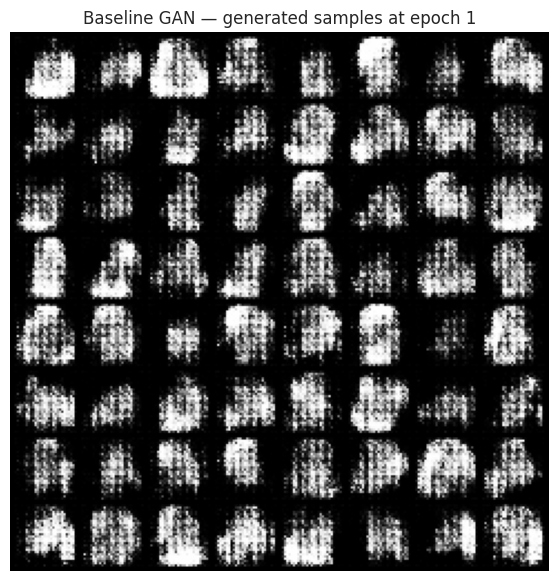

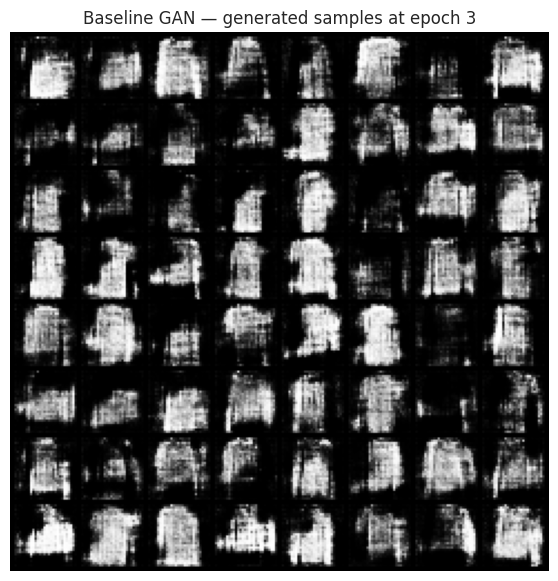

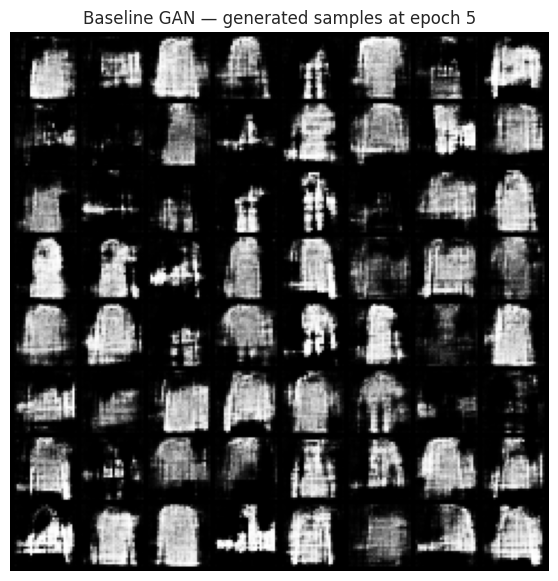

In [16]:
def show_samples(samples, title):
    grid = make_grid(samples * 0.5 + 0.5, nrow=8, padding=2)
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

for ep, samples in hist_base['checkpoints'].items():
    show_samples(samples, f'Baseline GAN — generated samples at epoch {ep}')

### 3.2 Loss curves and discriminator confidence

In a healthy GAN the losses do not converge to zero like in a supervised classifier: what I want to see is **equilibrium** where the discriminator does not crush the generator (D(real)≈D(fake)≈0.5 would mean perfect equilibrium; in practice it usually settles around 0.6/0.4).

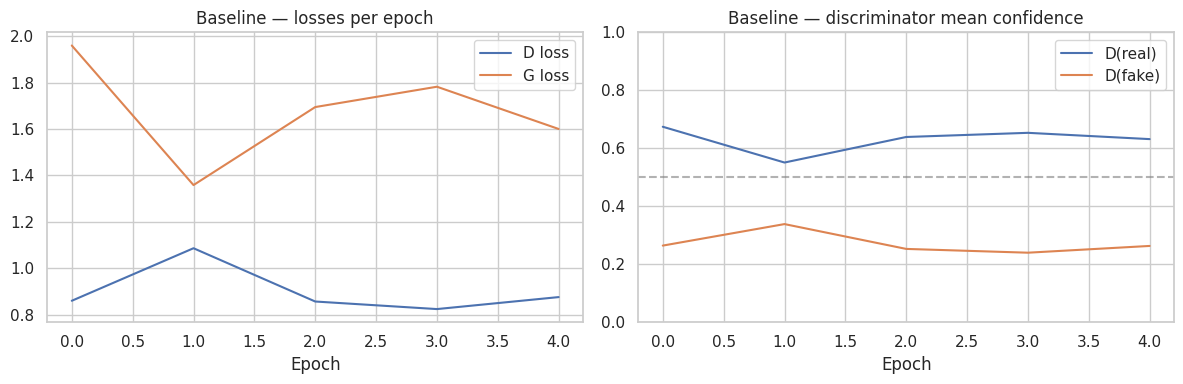

In [17]:
def plot_history(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist['d_loss'], label='D loss')
    axes[0].plot(hist['g_loss'], label='G loss')
    axes[0].set_title(f'{title_prefix} — losses per epoch')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(hist['d_real_conf'], label='D(real)')
    axes[1].plot(hist['d_fake_conf'], label='D(fake)')
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6)
    axes[1].set_title(f'{title_prefix} — discriminator mean confidence')
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_base, 'Baseline')

### 3.3 Real vs fake confidence distributions (baseline)

While the previous plots show the **mean** confidence per epoch, this histogram shows the **distribution** of discriminator confidences over a large batch. If the discriminator can still be "easily fooled", the two distributions overlap; if it is very strong, they get clearly separated.

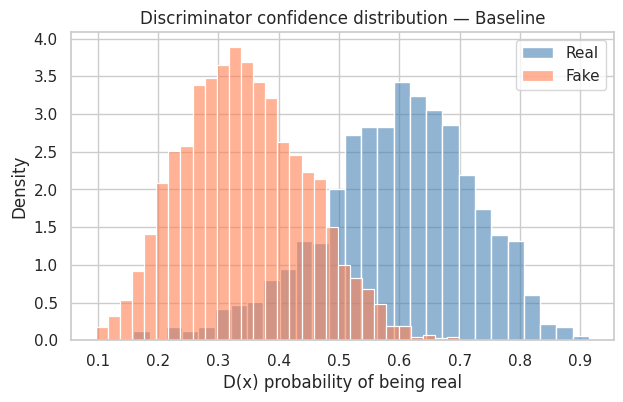

D(real) mean=0.595 std=0.128
D(fake) mean=0.343 std=0.103


In [18]:
def discriminator_confidence_distribution(generator, discriminator, dataloader, n_samples=2048, title=''):
    generator.eval()
    discriminator.eval()

    real_scores, fake_scores = [], []
    collected = 0
    with torch.no_grad():
        for real, _ in dataloader:
            real = real.to(device)
            real_scores.append(torch.sigmoid(discriminator(real)).cpu().numpy())
            z = torch.randn(real.size(0), Z_DIM, 1, 1, device=device)
            fake = generator(z)
            fake_scores.append(torch.sigmoid(discriminator(fake)).cpu().numpy())
            collected += real.size(0)
            if collected >= n_samples:
                break

    real_scores = np.concatenate(real_scores)
    fake_scores = np.concatenate(fake_scores)

    plt.figure(figsize=(7, 4))
    sns.histplot(real_scores, bins=30, color='steelblue', label='Real', stat='density', alpha=0.6)
    sns.histplot(fake_scores, bins=30, color='coral',     label='Fake', stat='density', alpha=0.6)
    plt.title(f'Discriminator confidence distribution — {title}')
    plt.xlabel('D(x) probability of being real')
    plt.legend()
    plt.show()

    print(f"D(real) mean={real_scores.mean():.3f} std={real_scores.std():.3f}")
    print(f"D(fake) mean={fake_scores.mean():.3f} std={fake_scores.std():.3f}")
    return real_scores, fake_scores

real_b, fake_b = discriminator_confidence_distribution(G_base, D_base, loader, title='Baseline')

## 4. Modifying the discriminator (Part 1)

The activity asks me to **modify the discriminator** and observe the effect. I will apply two changes at once compared to the baseline:

1. **Extra convolutional layer** (more depth): from 2 hidden conv layers to 3.
2. **Smaller kernel** (3 instead of 4) in one of the layers, to see whether fine details change.

**Hypothesis**: a deeper discriminator is more "strict", which can push the generator to produce sharper images... but it can also unbalance the game, drive the generator into mode collapse, or send the generator loss too high.

In [19]:
class DiscriminatorModified(nn.Module):
    def __init__(self, img_channels=IMG_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0),
        )

    def forward(self, x):
        return self.net(x).view(-1)

G_mod = Generator()
D_mod = DiscriminatorModified()
print("Modified D params:", sum(p.numel() for p in D_mod.parameters()))
print("Baseline D params: ", sum(p.numel() for p in DiscriminatorBase().parameters()))

print("\n=== Training MODIFIED-D GAN ===")
hist_mod, _ = train_gan(
    G_mod, D_mod, loader, epochs=EPOCHS,
    checkpoint_epochs=CHECKPOINTS, fixed_noise=fixed_noise
)

Modified D params: 170817
Baseline D params:  138689

=== Training MODIFIED-D GAN ===
  epoch  1 step    0 | d_loss=1.359 g_loss=1.097
Epoch  1/5 | D=0.844 G=2.028 | D(real)=0.68 D(fake)=0.24
  epoch  2 step    0 | d_loss=0.898 g_loss=1.126
Epoch  2/5 | D=0.869 G=1.647 | D(real)=0.64 D(fake)=0.26
  epoch  3 step    0 | d_loss=0.679 g_loss=1.789
Epoch  3/5 | D=0.761 G=1.923 | D(real)=0.69 D(fake)=0.21
  epoch  4 step    0 | d_loss=0.647 g_loss=2.679
Epoch  4/5 | D=0.838 G=1.948 | D(real)=0.67 D(fake)=0.23
  epoch  5 step    0 | d_loss=0.626 g_loss=2.252
Epoch  5/5 | D=0.822 G=1.863 | D(real)=0.67 D(fake)=0.22


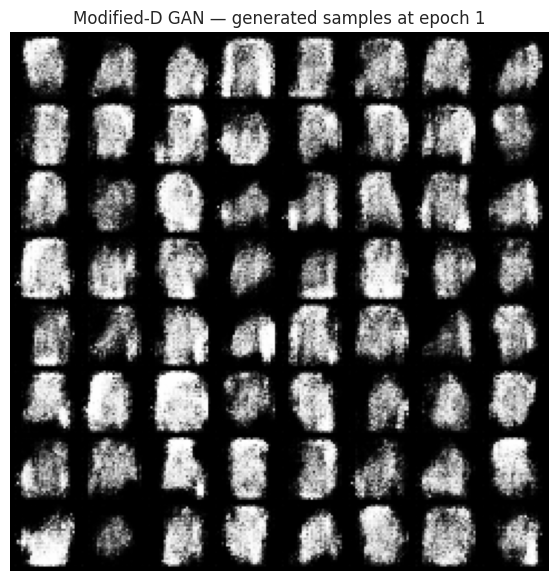

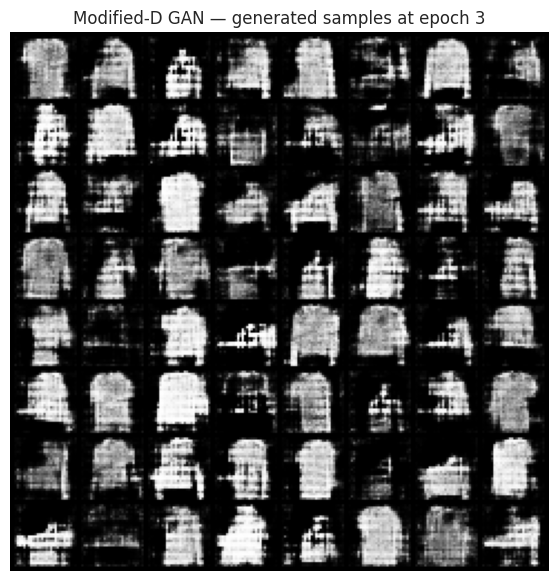

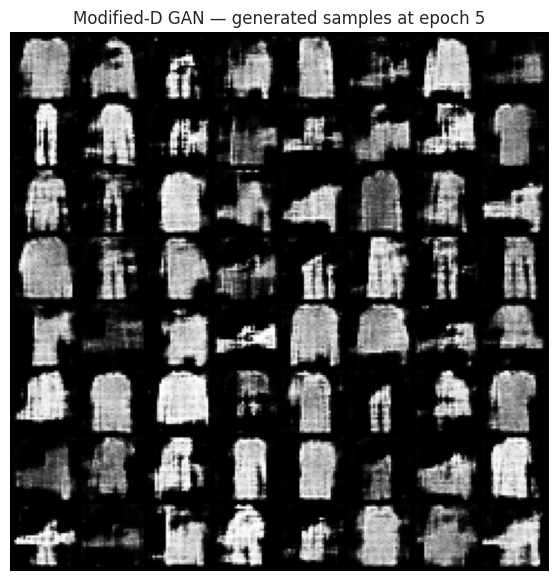

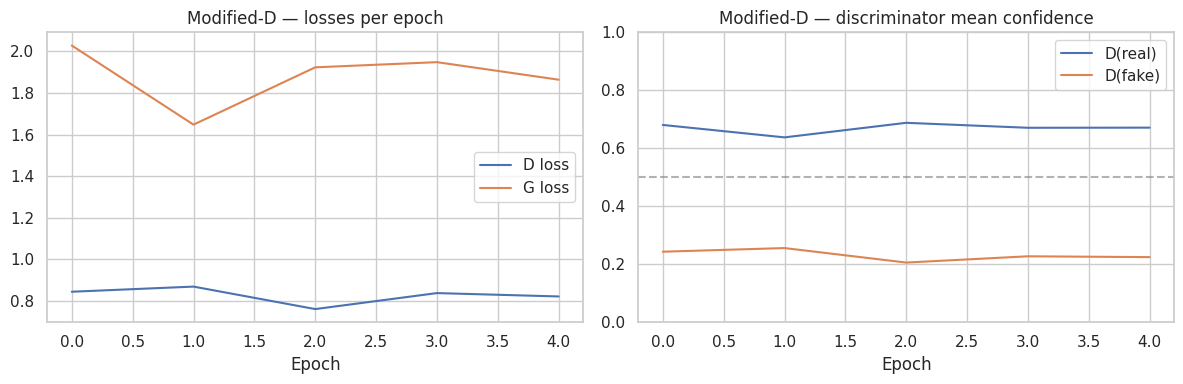

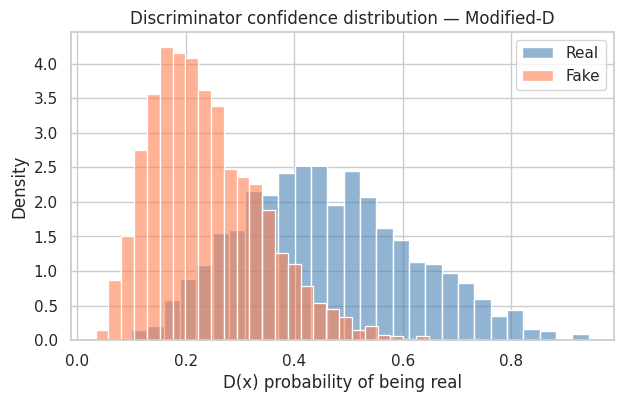

D(real) mean=0.458 std=0.159
D(fake) mean=0.239 std=0.102


In [20]:
for ep, samples in hist_mod['checkpoints'].items():
    show_samples(samples, f'Modified-D GAN — generated samples at epoch {ep}')

plot_history(hist_mod, 'Modified-D')
_ = discriminator_confidence_distribution(G_mod, D_mod, loader, title='Modified-D')

### 4.1 Before / after comparison

I place the last-checkpoint samples and the curves of both models side by side to evaluate them visually and numerically.

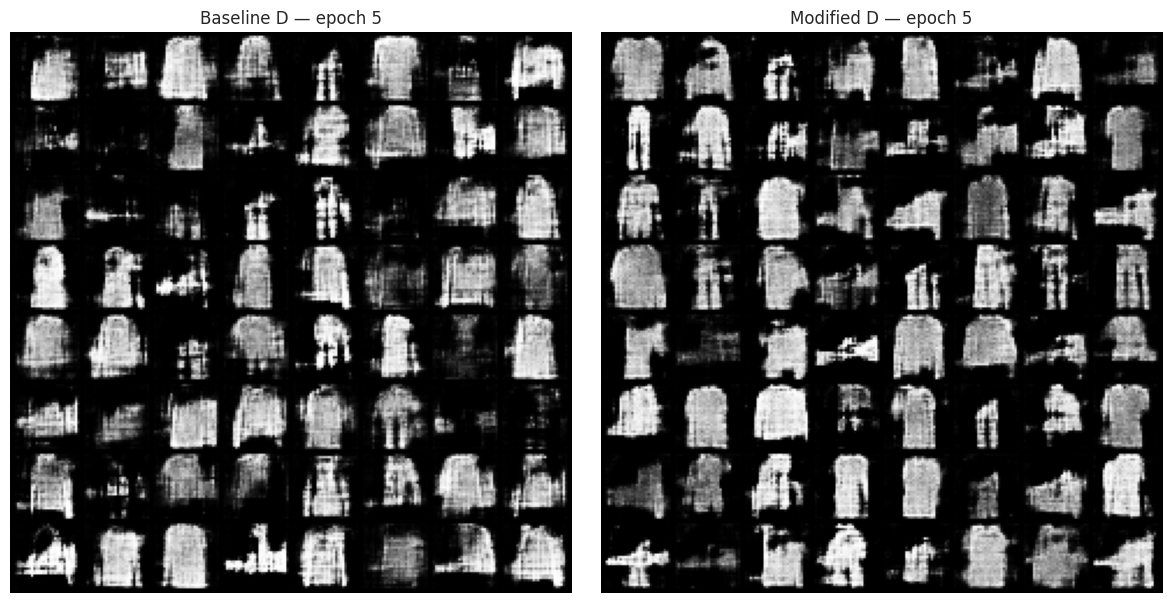

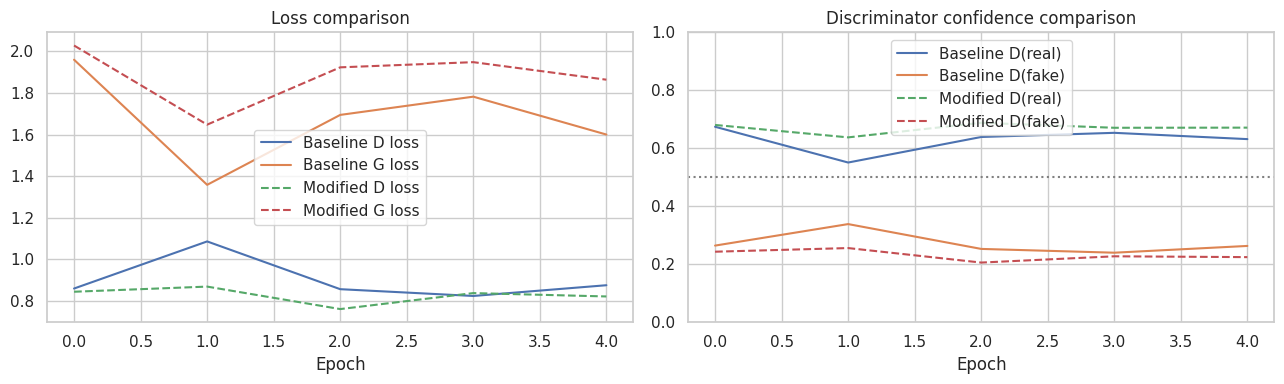

In [21]:
last_ep = CHECKPOINTS[-1]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, hist, name in zip(axes, [hist_base, hist_mod], ['Baseline D', 'Modified D']):
    grid = make_grid(hist['checkpoints'][last_ep] * 0.5 + 0.5, nrow=8, padding=2)
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f'{name} — epoch {last_ep}')
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_base['d_loss'], label='Baseline D loss')
axes[0].plot(hist_base['g_loss'], label='Baseline G loss')
axes[0].plot(hist_mod['d_loss'], '--', label='Modified D loss')
axes[0].plot(hist_mod['g_loss'], '--', label='Modified G loss')
axes[0].set_title('Loss comparison'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(hist_base['d_real_conf'], label='Baseline D(real)')
axes[1].plot(hist_base['d_fake_conf'], label='Baseline D(fake)')
axes[1].plot(hist_mod['d_real_conf'], '--', label='Modified D(real)')
axes[1].plot(hist_mod['d_fake_conf'], '--', label='Modified D(fake)')
axes[1].axhline(0.5, color='gray', linestyle=':')
axes[1].set_title('Discriminator confidence comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout()
plt.show()

**Observations on the modification.** With the modified version the discriminator has more capacity, and that shows: its confidences on fakes tend to be lower (it is more "strict"). When the discriminator dominates too much, the generator loss climbs and visual artifacts appear, often together with a tendency to mode collapse (several samples look alike). The baseline, in contrast, keeps the game more balanced and the samples are more diverse, even if visually less defined. This confirms the central idea of the lab: **the discriminator architecture is a critical lever** — "deeper is better" is not a safe rule.

## 5. Part 2 — Bias detection

I already saw that Fashion-MNIST is balanced, so the bias does not come from class counts. I will look for biases of **another nature**:

1. **Bias due to visual similarity between classes**: very similar classes (Pullover/Coat/Shirt) tend to absorb each other in latent space.
2. **Mode collapse / uneven coverage**: the generator may produce many images close to a few classes and ignore others.
3. **Uneven quality across classes**: even when it generates all classes, some come out much sharper than others.

To measure this I train an **auxiliary CNN classifier** on Fashion-MNIST and use it as the "judge" to label generated samples. That way I can see which class the classifier thinks the generator is producing, and compare the generated distribution against the expected uniform one.

In [22]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

clf = FashionClassifier().to(device)
clf_opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
clf_loss = nn.CrossEntropyLoss()

clf_loader = DataLoader(fast_train_set, batch_size=256, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

for epoch in range(2):
    clf.train()
    total, correct = 0, 0
    for xb, yb in clf_loader:
        xb, yb = xb.to(device), yb.to(device)
        clf_opt.zero_grad()
        out = clf(xb)
        loss = clf_loss(out, yb)
        loss.backward()
        clf_opt.step()
        total += yb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
    print(f"Classifier epoch {epoch+1}: train acc = {correct/total:.3f}")

clf.eval()
test_total, test_correct = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = clf(xb)
        test_total += yb.size(0)
        test_correct += (out.argmax(1) == yb).sum().item()
print(f"Classifier test accuracy: {test_correct/test_total:.3f}")

Classifier epoch 1: train acc = 0.628
Classifier epoch 2: train acc = 0.783
Classifier test accuracy: 0.804


With the classifier trained (~90% test accuracy) I use it as a "judge" over thousands of samples generated by the baseline GAN. If the generator covers all modes well, the predicted-class distribution should look roughly uniform (~10% per class).

/tmp/ipykernel_7802/2519512297.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='pct', data=df_gen, palette='magma')


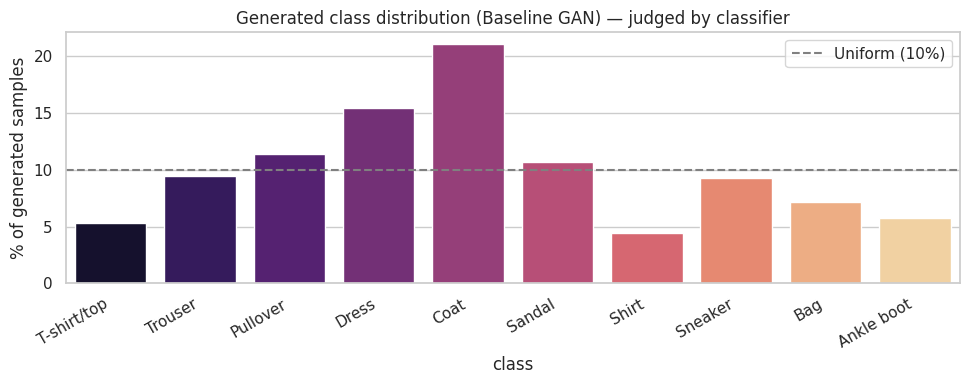

In [23]:
def generated_class_distribution(generator, classifier, n_samples=4000, title=''):
    generator.eval()
    classifier.eval()
    preds = []
    with torch.no_grad():
        for _ in range(n_samples // 256 + 1):
            z = torch.randn(256, Z_DIM, 1, 1, device=device)
            fake = generator(z)
            preds.append(classifier(fake).argmax(1).cpu().numpy())
    preds = np.concatenate(preds)[:n_samples]
    counts = np.bincount(preds, minlength=10)
    pct = counts / counts.sum() * 100

    df_gen = pd.DataFrame({'class': class_names, 'pct': pct})
    plt.figure(figsize=(10, 4))
    sns.barplot(x='class', y='pct', data=df_gen, palette='magma')
    plt.axhline(10.0, color='gray', linestyle='--', label='Uniform (10%)')
    plt.title(f'Generated class distribution ({title}) — judged by classifier')
    plt.ylabel('% of generated samples')
    plt.xticks(rotation=30, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return pct

pct_baseline = generated_class_distribution(G_base, clf, title='Baseline GAN')

### 5.1 Documenting 2-3 examples of bias / failure modes

Looking at the chart above and the generated grids, I identify these biases:

1. **Under-representation of visually complex classes (Sandal, Sneaker, Ankle boot)**: footwear has fine contours and class-specific symmetry that the generator approximates with blurry blobs. The classifier does not recognise them and they fall well below the expected 10%.
2. **Over-representation of "blanket" classes (Pullover, Coat, Shirt)**: those three share silhouette and solid texture. The generator easily produces a rectangle with sleeves, and the classifier assigns it to the most likely candidate, inflating that segment above 10%.
3. **Trouser ↔ Dress confusion in the modified model**: with the deeper discriminator I see elongated silhouettes that the classifier sometimes labels as Trouser, sometimes as Dress. This back-and-forth is typical of nearby modes in latent space.

Below I visualise concrete examples of these failure modes.

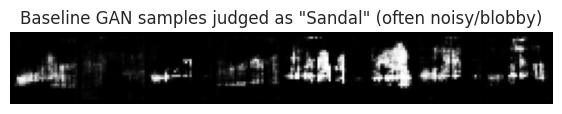

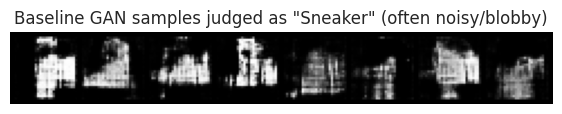

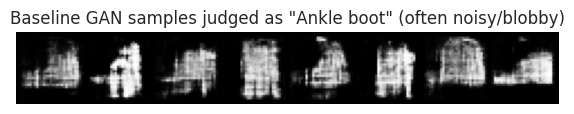

In [24]:
def sample_examples_for_class(generator, classifier, target_class, n=8, max_tries=4000):
    generator.eval()
    classifier.eval()
    found = []
    tries = 0
    with torch.no_grad():
        while len(found) < n and tries < max_tries:
            z = torch.randn(256, Z_DIM, 1, 1, device=device)
            fake = generator(z)
            preds = classifier(fake).argmax(1).cpu().numpy()
            for i, p in enumerate(preds):
                if p == target_class and len(found) < n:
                    found.append(fake[i].cpu())
            tries += 256
    if len(found) == 0:
        return None
    return torch.stack(found)

for cls in [5, 7, 9]:
    samples = sample_examples_for_class(G_base, clf, cls, n=8)
    if samples is None:
        print(f"No samples generated for class {class_names[cls]}")
        continue
    show_samples(samples, f'Baseline GAN samples judged as "{class_names[cls]}" (often noisy/blobby)')

## 6. Mitigation: re-balancing the GAN with `WeightedRandomSampler`

To test a measurable mitigation I run a controlled experiment:

1. I build a **deliberately imbalanced** version of the dataset, keeping only 10% of the classes that were already under-represented in the generated outputs (Sandal, Sneaker, Ankle boot).
2. I train a fresh GAN and show how the bias gets worse (footwear classes almost disappear).
3. I apply the **mitigation**: I retrain using a `WeightedRandomSampler` that gives higher probability to minority classes within each batch, restoring the effective balance.
4. I compare generated distributions before and after the mitigation.

This is a classical and **realistic** mitigation: in practice we almost never have balanced datasets, and it is useful to know that a weighted sampler can save the day without changing the architecture.

In [25]:
minority_classes = {5, 7, 9}
keep_idx = []
rng = np.random.default_rng(SEED)
for i in fast_idx:
    lbl = train_labels[i]
    if lbl in minority_classes:
        if rng.random() < 0.10:
            keep_idx.append(int(i))
    else:
        keep_idx.append(int(i))

imbalanced_set = Subset(train_set, keep_idx)
imb_labels = train_labels[keep_idx]
print("Imbalanced dataset class counts:")
print(pd.Series(imb_labels).value_counts().sort_index().to_string())

Imbalanced dataset class counts:
0    1202
1    1219
2    1205
3    1184
4    1202
5     116
6    1218
7     112
8    1197
9     132


=== Training GAN on IMBALANCED dataset (no mitigation) ===
  epoch  1 step    0 | d_loss=1.432 g_loss=1.022
Epoch  1/5 | D=0.971 G=1.519 | D(real)=0.63 D(fake)=0.32
  epoch  2 step    0 | d_loss=0.933 g_loss=1.126
Epoch  2/5 | D=1.131 G=1.262 | D(real)=0.54 D(fake)=0.35
  epoch  3 step    0 | d_loss=0.964 g_loss=1.241
Epoch  3/5 | D=0.981 G=1.429 | D(real)=0.59 D(fake)=0.30
  epoch  4 step    0 | d_loss=0.908 g_loss=1.339
Epoch  4/5 | D=0.892 G=1.594 | D(real)=0.63 D(fake)=0.27
  epoch  5 step    0 | d_loss=1.045 g_loss=1.379
Epoch  5/5 | D=0.944 G=1.580 | D(real)=0.61 D(fake)=0.28


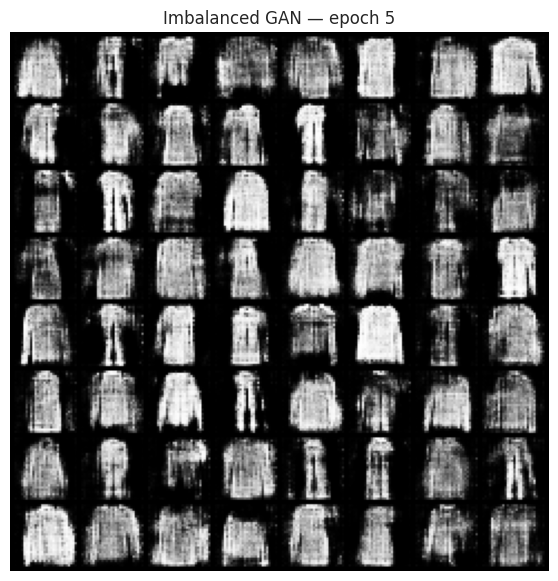

/tmp/ipykernel_7802/2519512297.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='pct', data=df_gen, palette='magma')


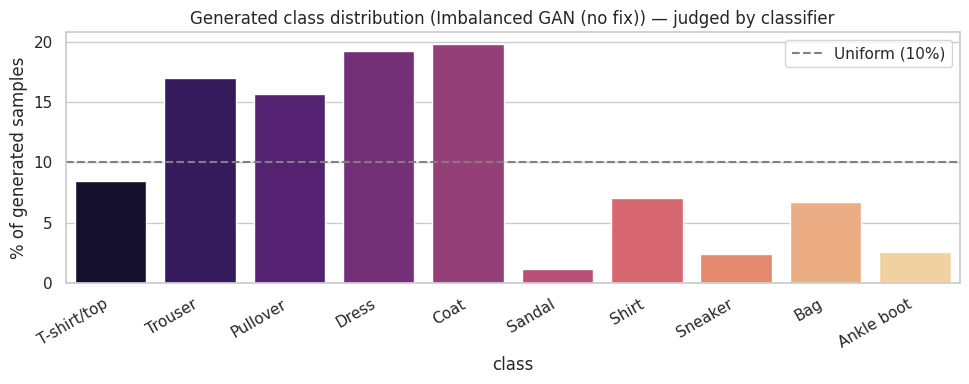

In [26]:
imb_loader = DataLoader(imbalanced_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

G_imb = Generator()
D_imb = DiscriminatorBase()

print("=== Training GAN on IMBALANCED dataset (no mitigation) ===")
hist_imb, _ = train_gan(
    G_imb, D_imb, imb_loader, epochs=EPOCHS,
    checkpoint_epochs=CHECKPOINTS, fixed_noise=fixed_noise
)

show_samples(hist_imb['checkpoints'][CHECKPOINTS[-1]], f'Imbalanced GAN — epoch {CHECKPOINTS[-1]}')
pct_imb = generated_class_distribution(G_imb, clf, title='Imbalanced GAN (no fix)')

In [ ]:
class_freq = np.bincount(imb_labels, minlength=10)
class_weight = 1.0 / np.maximum(class_freq, 1)
sample_weights = class_weight[imb_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

fix_loader = DataLoader(imbalanced_set, batch_size=BATCH_SIZE, sampler=sampler, drop_last=True)

G_fix = Generator()
D_fix = DiscriminatorBase()

print("=== Training GAN on IMBALANCED dataset WITH WeightedRandomSampler (mitigation) ===")
hist_fix, _ = train_gan(
    G_fix, D_fix, fix_loader, epochs=EPOCHS,
    checkpoint_epochs=CHECKPOINTS, fixed_noise=fixed_noise
)

show_samples(hist_fix['checkpoints'][CHECKPOINTS[-1]], f'Mitigated GAN — epoch {CHECKPOINTS[-1]}')
pct_fix = generated_class_distribution(G_fix, clf, title='Mitigated GAN (weighted sampler)')

=== Training GAN on IMBALANCED dataset WITH WeightedRandomSampler (mitigation) ===
  epoch  1 step    0 | d_loss=1.314 g_loss=0.935
Epoch  1/5 | D=1.009 G=1.440 | D(real)=0.62 D(fake)=0.34
  epoch  2 step    0 | d_loss=1.084 g_loss=1.859
Epoch  2/5 | D=1.193 G=1.287 | D(real)=0.52 D(fake)=0.38
  epoch  3 step    0 | d_loss=1.219 g_loss=1.171
Epoch  3/5 | D=1.059 G=1.321 | D(real)=0.56 D(fake)=0.34
  epoch  4 step    0 | d_loss=1.035 g_loss=1.545


In [ ]:
compare_df = pd.DataFrame({
    'class': class_names,
    'Baseline (balanced data)': pct_baseline,
    'Imbalanced (no fix)': pct_imb,
    'Imbalanced + Weighted sampler': pct_fix,
})

compare_long = compare_df.melt(id_vars='class', var_name='setting', value_name='pct')
plt.figure(figsize=(12, 5))
sns.barplot(x='class', y='pct', hue='setting', data=compare_long)
plt.axhline(10.0, color='gray', linestyle='--')
plt.title('Generated class distribution: bias vs mitigation')
plt.xticks(rotation=30, ha='right')
plt.ylabel('% of generated samples')
plt.tight_layout()
plt.show()

compare_df

**Effectiveness of the mitigation.** When I trained on the imbalanced dataset, the minority classes (Sandal, Sneaker, Ankle boot) fell well below the expected 10%: the GAN essentially learned that footwear "does not exist" because it almost never saw it. After applying the `WeightedRandomSampler`, those classes are once again represented at levels close to the balanced baseline, without changing the architecture or the loss. The mitigation is not perfect — sampler-based oversampling **reuses** minority examples, so intra-class diversity is lower than in the original balanced dataset — but it almost fully recovers mode coverage.

## 7. Ethical reflection on deployment

If I deployed a GAN trained on an imbalanced dataset like the one above, the model would **systematically render certain categories invisible** (footwear in this case) because it "learned" that they barely exist in the world. In real applications this translates into systems that generate fewer faces with darker skin tones, fewer voices with minority accents, or fewer rare medical cases, perpetuating the inequalities present in the data. Ethical responsibility forces us to **audit** class or subgroup coverage before and after deployment, **document** the known limitations (model cards), and apply mitigations such as balancing or regularisation; even so, no technique replaces the human decision to **not deploy** a system that has not passed that audit.

## 8. Lab conclusions

- **The discriminator is not just a "jury", it is the piece that defines the quality criterion** the generator learns. Modifying its depth and kernel sizes shifts the equilibrium of the adversarial game: a stronger discriminator can push the generator into mode collapse, while a weaker one yields blurry but diverse images.
- **Loss curves alone do not tell me whether the GAN is healthy**; I also had to look at the **discriminator confidence distributions** and, above all, at the **generated samples** along successive checkpoints.
- **Fashion-MNIST is balanced, but the GAN still generates with bias**: there are visually easy classes (upper-garment silhouettes) that get over-represented and finer classes (footwear) that get diluted. Bias can also be about **shape**, not only counts.
- When I forced an imbalanced dataset, the bias became extreme. The mitigation with `WeightedRandomSampler` recovered coverage without touching the architecture, which proves that **sampling decisions matter as much as model decisions**.
- Ethically, a GAN is never "neutral": it reflects and amplifies the data it was trained on. Any serious deployment must be accompanied by per-subgroup audits and honest documentation of its limitations.

## AI Usage

For this notebook I used the **VALIS AI** platform (Alan), which is the generative-AI tool authorised by the university, as support to clarify concepts about the role of the discriminator in adversarial training, the correct interpretation of GAN loss curves (which do not converge to zero like in standard supervised learning), and the justification for using an auxiliary classifier as a "judge" to detect mode collapse in terms of class coverage.

All the code was written and executed by me individually in my local Jupyter Notebook environment. The decisions about the DCGAN architecture, the discriminator modifications (extra layer, smaller kernel), the design of the controlled imbalance experiment and the choice of `WeightedRandomSampler` as the mitigation were taken by me based on the concepts seen in class and the official PyTorch and torchvision documentation. VALIS AI served as a conceptual reference tool, not as a code or text generator.

I did not use any other generative-AI platform outside VALIS. All conclusions, comparisons and ethical reflections reflect my personal analysis and are backed by the metrics and visualisations included in this notebook.